In [1]:
print()

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from utils import get_gradcam,preprocess_image

In [3]:
from tensorflow.keras.models import load_model
model=load_model('C:\\Users\\PratushPc\\OneDrive\\Desktop\\ExCV\\models\\best_model.keras')

In [4]:
classes={ 0: 'COVID', 1: 'Normal', 2: 'Viral Pneumonia' }
for layer in model.layers[-20:]:
    print(layer.name)

conv5_block14_concat
conv5_block15_0_bn
conv5_block15_0_relu
conv5_block15_1_conv
conv5_block15_1_bn
conv5_block15_1_relu
conv5_block15_2_conv
conv5_block15_concat
conv5_block16_0_bn
conv5_block16_0_relu
conv5_block16_1_conv
conv5_block16_1_bn
conv5_block16_1_relu
conv5_block16_2_conv
conv5_block16_concat
bn
relu
global_average_pooling2d
dropout
dense


0.7750489
(1, 224, 224, 3)


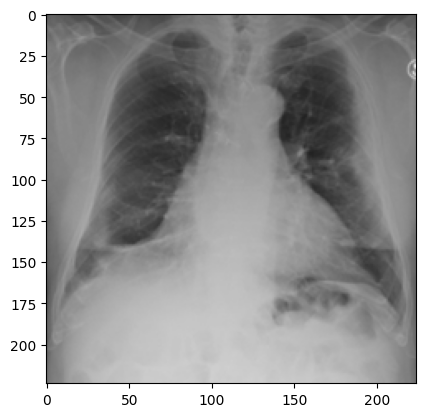

In [5]:
last_conv_layer='conv5_block16_2_conv'

import cv2
from tensorflow.keras.applications.densenet import preprocess_input

img_path='C:/Users/PratushPc/OneDrive/Desktop/ExCV/data/COVID_19_dataset/test/COVID/COVID-87.png'
img,processed_img=preprocess_image(img_path)
prediction=model.predict(processed_img,verbose=0)[0]
conf=np.max(prediction)
print(conf)
print(img.shape)
plt.imshow(img[0])

In [6]:
NORMAL_IMG_PATH='C:/Users/PratushPc/OneDrive/Desktop/ExCV/data/COVID_19_dataset/test/Normal/Normal-20.png'
COVID_ERROR_IMG_PATH='C:/Users/PratushPc/OneDrive/Desktop/ExCV/data/COVID_19_dataset/test/COVID/COVID-56.png'
COVID_IMG_PATH='C:/Users/PratushPc/OneDrive/Desktop/ExCV/data/COVID_19_dataset/test/COVID/COVID-114.png'
VIRAL_PNEUMONIA_IMG_PATH='C:/Users/PratushPc/OneDrive/Desktop/ExCV/data/COVID_19_dataset/test/Viral Pneumonia/Viral Pneumonia-41.png'

(-0.5, 223.5, 223.5, -0.5)

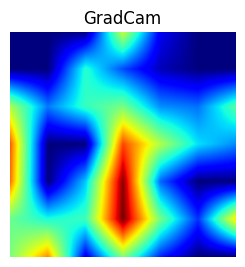

In [7]:
plt.subplot(121)
cam=get_gradcam(model,COVID_IMG_PATH,0)
plt.imshow(cam,cmap='jet')
plt.title("GradCam")
plt.axis('off')


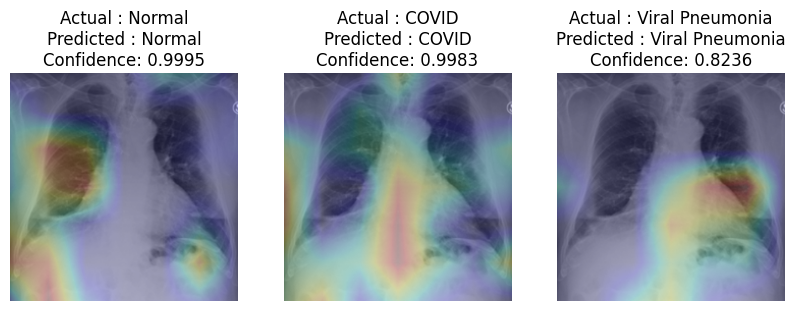

In [8]:
fig,axes=plt.subplots(1,3,figsize=(10,5))
for img_path,ax in zip([NORMAL_IMG_PATH,COVID_IMG_PATH,VIRAL_PNEUMONIA_IMG_PATH],axes):
    simg,sprocessed_img=preprocess_image(img_path)
    pred=model.predict(sprocessed_img,verbose=0)[0]
    confidence=np.max(pred)
    pred_idx=np.argmax(pred)
    
    cam=get_gradcam(
        model,
        img_path,
        pred_idx
    )
    cam=(cam-cam.min())/(cam.max()-cam.min())

    ax.imshow(img[0])
    ax.imshow(cam,alpha=0.2,cmap='jet')
    ax.set_title("Actual : "+img_path.split("/")[-2]+"\nPredicted : "+classes[pred_idx]+"\nConfidence: {:.4f}".format(confidence))
    ax.axis("off")
    

Text(0.5, 1.0, 'Actual : COVID\nPredicted : Normal\nConfidence: 0.5750')

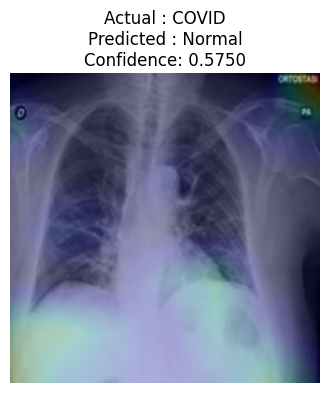

In [9]:
simg,sprocessed_img=preprocess_image(COVID_ERROR_IMG_PATH)
pred=model.predict(sprocessed_img,verbose=0)[0]
confidence=np.max(pred)
pred_idx=np.argmax(pred)

cam=get_gradcam(
    model,
    COVID_ERROR_IMG_PATH,
    pred_idx
)
 
plt.figure(figsize=(4,5))
plt.imshow(simg[0])
plt.imshow(cam,alpha=0.2,cmap='jet')
plt.axis("off")
plt.title("Actual : COVID"+"\nPredicted : "+classes[pred_idx]+"\nConfidence: {:.4f}".format(confidence))